# QF 627 Programming and Computational Finance
## Problem Set `7` | `Questions`

> Hi, Team 👋

> The exercise requires you to solve two overarching sets of questions. As with our previous exercise problem sets, while answering the questions you will be able to incorporate what you learned in class and consolidate your understanding.

> Enjoy 🤞

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [347]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [348]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 <font color = "purple"> Bigger Question 1. 

> Here's something that's familiar to you, with a few minor tweaks.

### Please create a predictive model for the weekly return of AMZN stock. You will use supervised learning for your predictive modelling.

> As you learned in class, to do this it is essential to know what factors are related to Amazon’s stock price, and to incorporate as much information as you can into the model.

> Among the three major factors (correlated assets, technical indicators, and fundamental analysis), you will use correlated assets and technical indicators as features here.

    Step 1. Use 75% of your data for the training of your algorithm, and 25% for the testing set.

    Step 2. For your feature engineering...
    
> Our operational definition of `outcome` (`Y`) is the weekly return of Amazon (AMZN). The number of trading days in a week is assumed to be five, and we compute the return using five trading days. 
<br>
    
* <font color = "green"> NOTE: The lagged five-day variables embed the time series component by using a time-delay approach, where the lagged variable is included as one of the predictor variables. This step translates the time series data into a supervised regression-based model framework.
<br>    
    
> For `input features` (`predictors`; `Xs`), we use (The variables used as predictors are as follows) ...

> `Correlated assets`

* lagged five-day returns of stocks (AAPL, MSFT, F);
* currency exchange rates (USD/JPY and GBP/USD);
* indices (S&P 500, Dow Jones, and VIX);
* lagged five-day, 15-day, 30-day, and 60-day returns of AMZN.

> `Technical indicators`

* 21-day, 63-day, and 252-day moving averages;
* 10-day, 30-day, and 200-day exponential moving averages.

    
    Step 3. For your algorithm of choices, please assess the model performance of the following algorithms: 

* Linear Regression
* Elastic Net
* LASSO
* Support Vector Machine
* K-Nearest Neighbor
* ARIMA
* Decision Tree
* Extra Trees 
* Random Forest
* Gradient Boosting Tree
* Adaptive Boosting
    
    
    Step 4. For this exercise, hyperparameter tuning won’t be requested. 
    
    Step 5. But make sure to compare the model performance of the above algorithms.

> The metric for assessing model performance will be mean squared error (`MSE`).
<br>

> Show which of the algorithms perform relatively better by a comparison visualization of performance, for both the training and testing sets learned in class. 

    Step 6. Using the model of your choice, please visualize the actual vs. predicted (estimated) data.

# TODO list
1. download tickers data
2. compute X
3. join X and Y to get the same index
4. train test split
5. regress against models
6. get positions and signals for each strat
7. compute returns and cum rets
8. compute mse for all
9. plot for one of the models

### Below are the lines of code that lead to an answer:

In [349]:
target_ticker = "AMZN"
tickers_x = [
    "AMZN", "AAPL", "MSFT", "F",     # Stocks
    "^GSPC", "^DJI", "^VIX",         # Indices
    "JPY=X", "GBPUSD=X"           # FX rates
]
tickers_y = tickers_x[:4]

df_x =\
(
    yf.download(
        tickers_x,
        start = dt.datetime(2013, 1, 7),
    )
)['Close']

df_y =\
(
    yf.download(
        tickers_y,
        start = dt.datetime(2013, 1, 7),
        interval = '1wk'
    )
)['Close']
# df_y.index[1].day_name()

[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  4 of 4 completed


In [350]:
x_list = {}

In [351]:
## compute fwd return for y target

## compute lagged 5, 15, 30, 60 day returns of amzn
## compute lagged 5 for other tickers_y
# lag_ret_wks = [1, 3, 6, 12]
# for lag in lag_ret_wks:
#     for ticker in tickers_y:
#         if lag > 1 and ticker != target_ticker:
#             continue
#         df_y[f'{ticker}_{lag}wk_ret'] = df_y[ticker].ffill().pct_change(lag)

# x_list["fwd_rets"] = df_y.filter(like='_ret').drop(columns=[f"{target_ticker}_1wk_ret"])    
#                                                 # drop to avoid duplication
# # df_y

lag_ret_wks = [5, 15, 30, 60]
for lag in lag_ret_wks:
    for ticker in tickers_x[:4]:
        if lag > 5 and ticker != target_ticker:
            continue
        df_x[f'{ticker}_{lag//5}wk_ret'] = df_x[ticker].ffill().pct_change(lag)

x_list["fwd_rets"] = df_x.filter(like='wk_ret').drop(columns=[f"{target_ticker}_1wk_ret"])    
                                                # drop to avoid duplication
df_y = df_x[target_ticker].ffill().pct_change(5).to_frame(name=f"{target_ticker}_1wk_ret")

In [352]:
# x_list
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    ticker = df.columns[0]
    for window in sma_list:
        df[f"{ticker}_sma_{window}"] =\
        (
            df[ticker]
            .rolling(window = window,
                     min_periods = int(window * .8)
                    )
            .mean()
        )

    return df

def get_ema(df, ema_list):
    """
    Take DF and given list of EMA to enrich df when stock price is in first column
    """
    ticker = df.columns[0]
    for window in ema_list:
        df[f"{ticker}_ema_{window}"] =\
        (
            df[ticker]
            .ewm(span = window,
                 min_periods = window
                )
            .mean()
        )

    return df

## compute [21, 63, 252] day SMA of AMZN
sma_list = [21, 63, 252]

## compute [10, 30, 200] day EMA of AMZN
ema_list = [10, 30, 200]

x_list["sma"] = get_sma(df_x[[target_ticker]], sma_list).drop(columns=[target_ticker])  # drop to avoid duplication
x_list["ema"] = get_ema(df_x[[target_ticker]], ema_list).drop(columns=[target_ticker])


# # df.rolling(252, min_periods=240).mean()
# get_ema(df_x[[target_ticker]], ema_list)

In [353]:
x_list['ccy'] = df_x[["GBPUSD=X", "JPY=X"]]
x_list['indices'] = df_x[["^GSPC", "^DJI", "^VIX"]]

In [354]:
X = pd.concat([x_list[k] for k in x_list], axis=1)

In [355]:
# df_y

In [356]:
Y = df_y

In [357]:
# X.shape, Y.shape
## keep non-null of y
df = pd.concat([X, Y], axis=1).dropna(subset=[f"{target_ticker}_1wk_ret"]).ffill()
# df[df['^DJI'].isnull()]
# df.isnull().sum()
## nulls for windows and rets are at the start. Index nulls are sporadic, should be ok to ffill
df = df.dropna()

In [358]:
# df
X = df[df.columns[:-1]]
Y = df[df.columns[-1]]

In [359]:
X.shape, Y.shape

((3128, 17), (3128,))

## Step 1 train test split
now all the time steps are linked

In [360]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, shuffle=False)

## Step 2 feature engineering 

In [361]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [362]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((2346, 17), (782, 17), (2346,), (782,))

# Step 3 fit models


# Step 4 Grid Search

In [363]:

from sklearn.model_selection import GridSearchCV

# Step 5 model metrics

In [364]:
from sklearn.metrics import mean_squared_error

mse_results = {}

def get_mse_train_test(model, X_train, Y_train, X_test, Y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(Y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(Y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    mse_results[str(model_name)] = {'mse_train': mse_train, 'mse_test': mse_test}

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")

    return mse_train, mse_test

# mse_train, mse_test = get_mse_train_test(lr, X_train, Y_train, X_test, Y_test)


## 3.1 linear reg

In [365]:
import statsmodels.api as sm

# Ensure X_train is a DataFrame with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns, index=Y_train.index)
X_train_df = sm.add_constant(X_train_df) # Add intercept

lr = sm.OLS(Y_train, X_train_df).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AMZN_1wk_ret   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     177.7
Date:                Sun, 19 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:08:23   Log-Likelihood:                 4980.6
No. Observations:                2346   AIC:                            -9925.
Df Residuals:                    2328   BIC:                            -9821.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0052      0.001      8.583      0.000       0.004       0.006
AAPL_1wk_ret      0.0069      0.001      8.892      0.000       0.005       0.008
MSFT_1wk_ret      0.0151      0.001     19.232      0.000       0.014       0.017
F_1wk_ret         0.0041      0.001      6.144      0.000       0.003       0.005
AMZN_3wk_ret      0.0171      0.001     13.441      0.000       0.015       0.020
AMZN_6wk_ret      0.0041      0.001      2.880      0.004       0.001       0.007
AMZN_12wk_ret     0.0084      0.001      7.056      0.000       0.006       0.011
AMZN_sma_21       0.1640      0.064      2.551      0.011       0.038       0.290
AMZN_sma_63       0.2094      0.036      5.843      0.000       0.139       0.280
AMZN_sma_252      0.0051      0.024      0.211      0.833      -0.043       0.053
AMZN_ema_10      -0.0240      0.035     -0.687      0.492      -0.093       0.045
AMZN_ema_30      -0.3492      0.120     -2.905      0.004      -0.585      -0.113
AMZN_ema_200     -0.0105      0.039     -0.268      0.789      -0.088       0.067
GBPUSD=X         -0.0014      0.001     -1.572      0.116      -0.003       0.000
JPY=X            -0.0013      0.001     -1.472      0.141      -0.003       0.000
^GSPC             0.0022      0.005      0.395      0.693      -0.009       0.013
^DJI              0.0018      0.004      0.391      0.696      -0.007       0.011
^VIX              0.0036      0.001      3.463      0.001       0.002       0.006
==============================================================================
Omnibus:                      140.952   Durbin-Watson:                   0.460
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              542.102
Skew:                           0.148   Prob(JB):                    1.92e-118
Kurtosis:                       5.336   Cond. No.                         682.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [366]:
mse_train, mse_test = get_mse_train_test(lr, 
                                         sm.add_constant(pd.DataFrame(X_train, columns=X.columns, index=Y_train.index)), 
                                          Y_train, 
                                          sm.add_constant(pd.DataFrame(X_test, columns=X.columns, index=Y_test.index)), 
                                          Y_test,
                                          name="LR")

mse_train, mse_test

Mean Squared Error (MSE) for LR
MSE train: 0.000839
MSE test: 0.001151


(0.0008385190297209554, 0.0011512923010156134)

## 3.2 Elastic Net

* Elastic Net


In [367]:
# ----------------------------------------------------------------------------
# 1. ELASTIC NET
# ----------------------------------------------------------------------------
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=1000, random_state=42)
elastic_net.fit(X_train, Y_train)
y_pred_en = elastic_net.predict(X_test)
print(f"Elastic Net - RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_en)):.4f}")

# Hyperparameter tuning
param_grid_en = {
    'alpha': [0.01, 0.1, 10.0],
    'l1_ratio': [0.1, 0.9]
}
grid_en = GridSearchCV(ElasticNet(max_iter=1000), param_grid_en, cv=5, scoring='neg_root_mean_squared_error')
grid_en.fit(X_train, Y_train)
print(f"Best Elastic Net params: {grid_en.best_params_}")

Elastic Net - RMSE: 0.0311
Best Elastic Net params: {'alpha': 0.01, 'l1_ratio': 0.1}


In [368]:
mse_train, mse_test = get_mse_train_test(elastic_net, X_train, Y_train, X_test, Y_test)

Mean Squared Error (MSE) for ElasticNet
MSE train: 0.000910
MSE test: 0.000970



## 3.3 LASSO

* LASSO


In [369]:
# ----------------------------------------------------------------------------
# 2. LASSO
# ----------------------------------------------------------------------------
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=1000, random_state=42)
lasso.fit(X_train, Y_train)
y_pred_lasso = lasso.predict(X_test)
print(f"LASSO - MSE: {mean_squared_error(Y_test, y_pred_lasso):.4f}")

# Feature selection with LASSO
n_nonzero = np.sum(lasso.coef_ != 0)
# print(f"LASSO selected {n_nonzero} features out of {X_reg.shape[1]}")

LASSO - MSE: 0.0011


In [370]:
mse_train, mse_test = get_mse_train_test(lasso, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for Lasso
MSE train: 0.001089
MSE test: 0.001149




## 3.4 Support Vector Machine

* Support Vector Machine


In [371]:
# ----------------------------------------------------------------------------
# 3. SUPPORT VECTOR MACHINE (Regression)
# ----------------------------------------------------------------------------
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train, Y_train)
y_pred_svr = svr.predict(X_train)
print(f"SVR - RMSE: {np.sqrt(mean_squared_error(Y_train, y_pred_svr)):.4f}")

# Hyperparameter tuning
param_grid_svr = {
    'C': [0.1],
    'epsilon': [0.01, 0.1],
    'kernel': ['linear']
}
grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='neg_root_mean_squared_error')
grid_svr.fit(X_train, Y_train)  # Uncomment to run
print(f"Best SVR params: {grid_svr.best_params_}")

SVR - RMSE: 0.0359
Best SVR params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}


In [372]:
mse_train, mse_test = get_mse_train_test(grid_svr, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for SVR
MSE train: 0.000851
MSE test: 0.001235


## 3.5 K-Nearest Neighbor

* K-Nearest Neighbor

In [373]:
# ----------------------------------------------------------------------------
# 4. K-NEAREST NEIGHBOR (Regression)
# ----------------------------------------------------------------------------
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_reg.fit(X_train, Y_train)
y_pred_knn = knn_reg.predict(X_train)
print(f"KNN Regressor - RMSE: {np.sqrt(mean_squared_error(Y_train, y_pred_knn)):.4f}")

# Find optimal k
param_grid_knn = {'n_neighbors': range(1, 21)}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_root_mean_squared_error')
grid_knn.fit(X_train, Y_train)
print(f"Best k: {grid_knn.best_params_['n_neighbors']}")

KNN Regressor - RMSE: 0.0199


Best k: 10


In [374]:
mse_train, mse_test = get_mse_train_test(grid_knn, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for KNeighborsRegressor
MSE train: 0.000617
MSE test: 0.001295



## 3.6 ARIMA

* ARIMA


In [375]:
# ============================================================================
# 10. ARIMA (Time Series)
# ============================================================================
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.arima.model as stats
import warnings
warnings.filterwarnings('ignore')

baseline_ARIMA =\
(
    stats
    .ARIMA(endog = Y_train,
           exog = X_train,
           order = [1, 0, 0]
          )
)
arima = baseline_ARIMA.fit()

In [376]:
[key for key in mse_results.keys() ]

['LR', 'ElasticNet', 'Lasso', 'SVR', 'KNeighborsRegressor']

In [377]:
y_pred_arima = arima.predict(
    start = 0,
    end = X.shape[0] -1,
    exog = X_test
)

# y_pred_arima

In [378]:
mse_train = \
(
    mean_squared_error(Y_train,
                       y_pred_arima[:len(Y_train)])
)
mse_test = \
(
    mean_squared_error(Y_test,
                       y_pred_arima[-len(Y_test):])
)

In [379]:
name = getattr(arima, 'name', None) or arima.__class__.__name__
mse_results[name] = {'mse_train': mse_train, 'mse_test': mse_test}


## 3.7 Decision Tree

* Decision Tree


In [380]:
# ----------------------------------------------------------------------------
# 5. DECISION TREE
# ----------------------------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train, Y_train)
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree - MSE: {mean_squared_error(Y_test, y_pred_dt):.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': [f'feature_{i}' for i in range(X_train.shape[1])],
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)
print("Top 5 important features (DT):")
print(feature_importance_dt.head())


Decision Tree - MSE: 0.0025
Top 5 important features (DT):
       feature  importance
1    feature_1    0.421019
3    feature_3    0.236489
4    feature_4    0.065421
0    feature_0    0.045098
12  feature_12    0.038364


In [381]:
mse_train, mse_test = get_mse_train_test(dt, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for DecisionTreeRegressor
MSE train: 0.000308
MSE test: 0.002519



## 3.8 Extra Trees

* Extra Trees


In [382]:
# ----------------------------------------------------------------------------
# 6. EXTRA TREES
# ----------------------------------------------------------------------------
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
et.fit(X_train, Y_train)
y_pred_et = et.predict(X_test)
print(f"Extra Trees - RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_et)):.4f}")


Extra Trees - RMSE: 0.0306


In [383]:
mse_train, mse_test = get_mse_train_test(et, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for ExtraTreesRegressor
MSE train: 0.000293
MSE test: 0.000937



## 3.9 Random Forest

* Random Forest


In [384]:
# ----------------------------------------------------------------------------
# 7. RANDOM FOREST
# ----------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest - RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_rf)):.4f}")

# Hyperparameter tuning (commented out - uncomment to run)
param_grid_rf = {
    'n_estimators': [50, 200],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                       param_grid_rf, cv=3, scoring='neg_root_mean_squared_error')
grid_rf.fit(X_train, Y_train)
print(f"Best RF params: {grid_rf.best_params_}")

Random Forest - RMSE: 0.0322
Best RF params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [385]:
mse_train, mse_test = get_mse_train_test(grid_rf, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for RandomForestRegressor
MSE train: 0.000317
MSE test: 0.001044


In [386]:
[key for key in mse_results.keys() ]

['LR',
 'ElasticNet',
 'Lasso',
 'SVR',
 'KNeighborsRegressor',
 'ARIMAResultsWrapper',
 'DecisionTreeRegressor',
 'ExtraTreesRegressor',
 'RandomForestRegressor']


## 3.10 Gradient Boosting Tree

* Gradient Boosting Tree


In [387]:
# ----------------------------------------------------------------------------
# 8. GRADIENT BOOSTING TREE
# ----------------------------------------------------------------------------
from sklearn.ensemble import GradientBoostingRegressor

gbt = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbt.fit(X_train, Y_train)
y_pred_gbt = gbt.predict(X_test)
print(f"Gradient Boosting - RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_gbt)):.4f}")


Gradient Boosting - RMSE: 0.0307


In [388]:
mse_train, mse_test = get_mse_train_test(gbt, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for GradientBoostingRegressor
MSE train: 0.000446
MSE test: 0.000943


In [389]:
[key for key in mse_results.keys() ]

['LR',
 'ElasticNet',
 'Lasso',
 'SVR',
 'KNeighborsRegressor',
 'ARIMAResultsWrapper',
 'DecisionTreeRegressor',
 'ExtraTreesRegressor',
 'RandomForestRegressor',
 'GradientBoostingRegressor']



## 3.11 Adaptive Boosting

* Adaptive Boosting

In [390]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, Y_train)
y_pred_ada = ada.predict(X_test)
print(f"AdaBoost - RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_ada)):.4f}")


AdaBoost - RMSE: 0.0316


In [391]:
mse_train, mse_test = get_mse_train_test(ada, 
                                         X_train, 
                                         Y_train, 
                                         X_test, 
                                         Y_test)

Mean Squared Error (MSE) for AdaBoostRegressor
MSE train: 0.000848
MSE test: 0.000999


In [392]:
mse_results

{'LR': {'mse_train': 0.0008385190297209554, 'mse_test': 0.0011512923010156134},
 'ElasticNet': {'mse_train': 0.0009098008626505033,
  'mse_test': 0.0009701993883427617},
 'Lasso': {'mse_train': 0.0010889544791683739,
  'mse_test': 0.001149360388039792},
 'SVR': {'mse_train': 0.000851025909466058, 'mse_test': 0.0012348299066999703},
 'KNeighborsRegressor': {'mse_train': 0.0006171877127430177,
  'mse_test': 0.0012947605454324493},
 'ARIMAResultsWrapper': {'mse_train': 0.00032127077655163866,
  'mse_test': 0.004423059306975437},
 'DecisionTreeRegressor': {'mse_train': 0.00030769253663871847,
  'mse_test': 0.0025191517240594416},
 'ExtraTreesRegressor': {'mse_train': 0.0002928331251922186,
  'mse_test': 0.000936562246571869},
 'RandomForestRegressor': {'mse_train': 0.00031725388065298037,
  'mse_test': 0.001044498222043871},
 'GradientBoostingRegressor': {'mse_train': 0.0004461340721016317,
  'mse_test': 0.0009428964836925069},
 'AdaBoostRegressor': {'mse_train': 0.0008475754537339953,
  '

In [393]:
[key for key in mse_results.keys() ]

['LR',
 'ElasticNet',
 'Lasso',
 'SVR',
 'KNeighborsRegressor',
 'ARIMAResultsWrapper',
 'DecisionTreeRegressor',
 'ExtraTreesRegressor',
 'RandomForestRegressor',
 'GradientBoostingRegressor',
 'AdaBoostRegressor']

### <font color = red> Answer 1 is presented in the cell below: </font>

In [394]:
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
metrics

,mse_train,mse_test,mse_ratio
ExtraTreesRegressor,0.000293,0.000937,3.198280
GradientBoostingRegressor,0.000446,0.000943,2.113482
ElasticNet,0.000910,0.000970,1.066387
AdaBoostRegressor,0.000848,0.000999,1.178767
RandomForestRegressor,0.000317,0.001044,3.292310
Lasso,0.001089,0.001149,1.055471
LR,0.000839,0.001151,1.373007
SVR,0.000851,0.001235,1.450990
KNeighborsRegressor,0.000617,0.001295,2.097839
DecisionTreeRegressor,0.000308,0.002519,8.187237


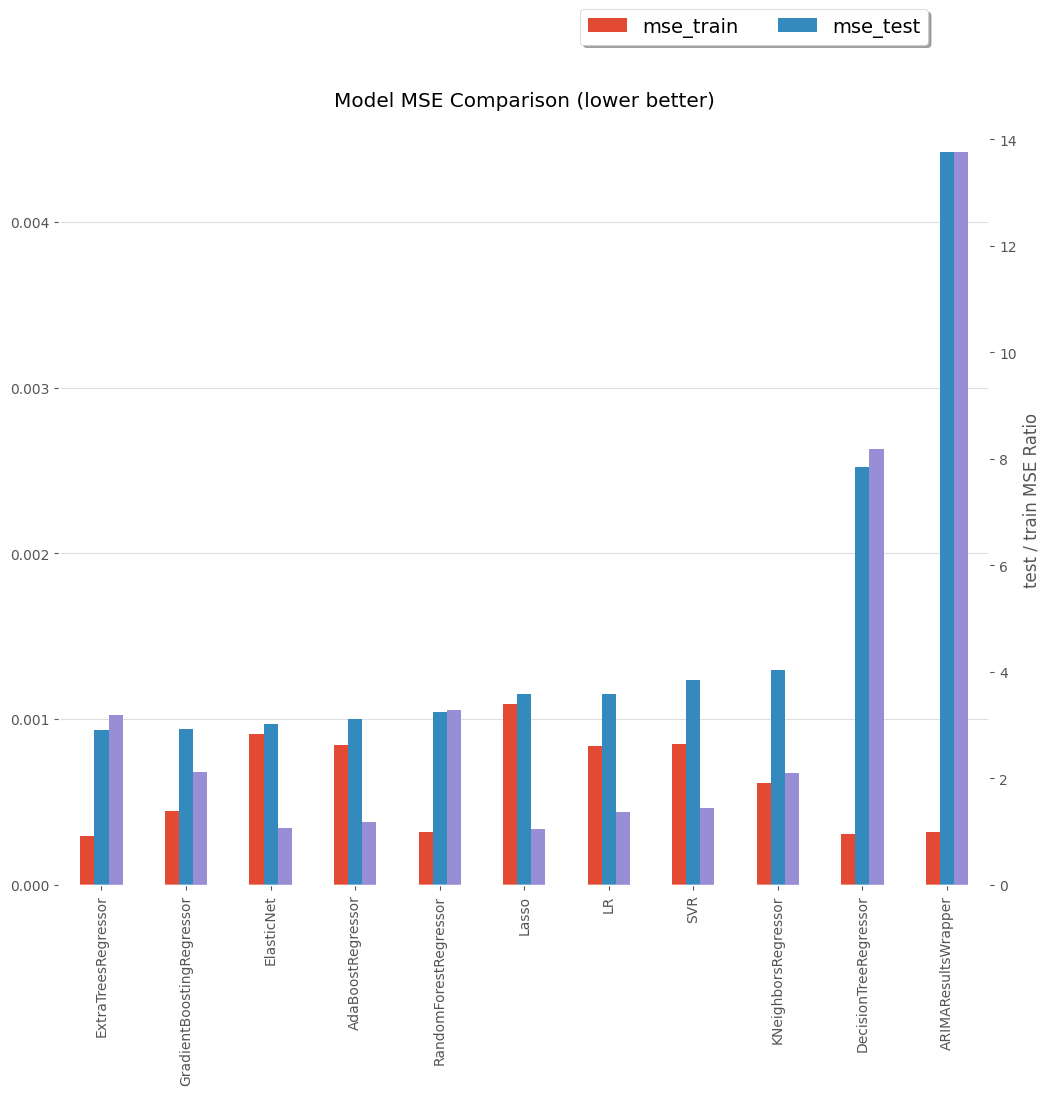

In [395]:
ax =\
(
    metrics.plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [396]:
comparison_df = \
pd.DataFrame({
    'Actual': Y_test.values.flatten() if hasattr(Y_test, 'values') else Y_test,
    'Predicted': y_pred_en
}, index=Y_test.index)

<Axes: title={'center': 'Elastic Net: Actual vs Predicted'}, xlabel='Date', ylabel='1-Week Forward Return'>

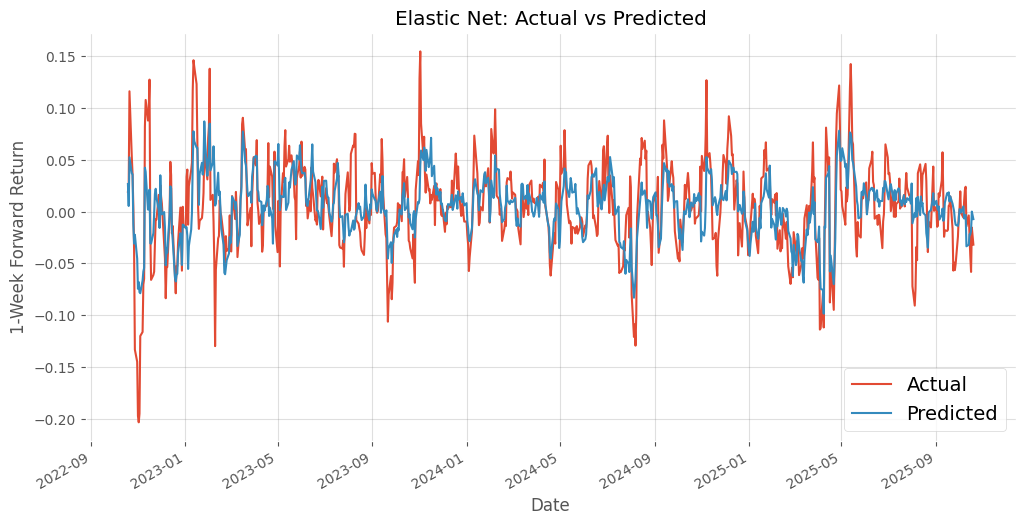

In [397]:
comparison_df.plot(
    title="Elastic Net: Actual vs Predicted",
    ylabel="1-Week Forward Return",
    xlabel="Date",
    figsize=(12, 6)
)

## <font color = blue> 👉 Questions 2 to 5 ask you to build, execute, and backtest a mean-reversion strategy, using `Relative Strength Index` (`RSI`). </font>

#### The Relative Strength Index (RSI) is an indicator that uses the closing prices of an asset to identify oversold and overbought conditions. 

> Most commonly, RSI is calculated using a 14-day period, and measured on a scale from zero to 100. (It is an oscillator.)

> Traders usually buy an asset when it is oversold (when its RSI is below 30) and sell when it is overbought (when its RSI is above 70). 

> More extreme overbought and oversold levels, such as 80 and 20, are used less frequently, and imply stronger momentum.

#### You are asked to build a trading strategy with the following set of rules.

### <font color = green> NOTE: Apple (`AAPL`) as our security of interest. The `investment horizon` will be three years between 2015 and 2017; your `capital` is USD 100,000; and there is a USD 5 flat `commission fee` per trade.

- You can go long and short.
<br>

- To calculate RSI, use 14 periods (trading days).
<br>

- Enter a long position if RSI crosses the lower threshold (standard value of 30), moving upwards. Exit the position when RSI becomes higher than the middle level (value of 50).
<br>

- Enter a short position if RSI crosses the upper threshold (standard value of 70), moving downwards. Exit the position when RSI becomes less than 50.
<br>

- Only one position can be open at a time.

### <font color = green> NOTE: The RSI is defined as follows:
    
### Calculating the RSI first requires the RS which requires an average value of n-many previous trading days. 
<br>
    
- As discussed, a value of 14 days is common for the RSI calculation. 
<br>
    
- The first RS value requires the price from all 14 of the first trading days. Often, this is a source of confusion with the RSI given successive values only require the most recent. 
   
    
    Step 1. For 14 periods, calculate the difference in price from the current period and the previous period
    
    Step 2. For each period, record each positive change in price as a gain and each negative change as a loss
    
    Step 3. On the 14th period, calculate the arithmetic mean of the gains and losses for the entire 14 day period (e.g. gains / 14 & losses / 14)
    
    Step 4. Use these values to calculate the RS
    
### <center> $ RS = \frac{AverageGain}{AverageLoss} $
    
    Step 5. Use the RS value to calculate the RSI
    
    Step 6. For each proceeding period, use only the previous RSI value to calculate the next average value 
    by multiplying by our lookback period – 1 (e.g., 13 for a lookback of 14).
    
    Step 7. Add the value obtained in Step 6 to the current day’s value (run this for both the gains and losses)
    
### <center> $ RSI = 100 - \frac{100}{1 + RS} $

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

1. download aapl data
2. get rsi
3. get positions and trades
4. calculate strat returns
4. instantiate capital. iterrows and calculate cap
    - calculate cap after returns
    - if trade not 0 then charge 5

In [412]:
def calculate_rsi(data, period=14):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas Series of closing prices
    period: RSI period (default 14)
    
    Returns:
    pandas Series with RSI values
    """
    # Calculate price changes
    delta = data.diff()
    
    # Separate gains and losses
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    # get first average
    avg_gain = pd.Series(index=data.index, dtype='float64')
    avg_loss = pd.Series(index=data.index, dtype='float64')

    # get first average
    avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
    avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

    # Calculate rolling averages
    for i in range(period + 1, len(data)): 
        avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
        avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

    # Calculate RS (Relative Strength)
    rs = avg_gain / avg_loss
    
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

In [413]:
aapl = yf.download("AAPL", 
                   start='2015-01-01',
                   end='2018-01-01')['Close']

[*********************100%***********************]  1 of 1 completed


In [414]:
aapl['rsi'] = calculate_rsi(aapl, period=14)

In [415]:
aapl.iloc[:15]

Ticker,AAPL,rsi
Date,,
2015-01-02,24.261047,NaN
2015-01-05,23.577570,NaN
2015-01-06,23.579790,NaN
2015-01-07,23.910442,NaN
2015-01-08,24.829130,NaN
2015-01-09,24.855753,NaN
2015-01-12,24.243296,NaN
2015-01-13,24.458548,NaN
2015-01-14,24.365347,NaN


In [435]:
lower_threshold = 30
upper_threshold = 70
mid = 50

aapl['positions'] =\
(
    np.where(
        (aapl['rsi'].shift(1) < lower_threshold) & (aapl['rsi'] > lower_threshold),1,
            np.where(
                (aapl['rsi'].shift(1) < mid) & (aapl['rsi'] > mid), 0,
                    np.where(
                        (aapl['rsi'].shift(1) > mid) & (aapl['rsi'] < mid), 0,
                            np.where(
                                (aapl['rsi'].shift(1) > upper_threshold) & (aapl['rsi'] < upper_threshold), -1, np.nan
                            )
                    )
            )
    )
)

In [417]:
aapl['positions'] = aapl['positions'].ffill().fillna(0)
aapl = aapl.dropna()

In [418]:
aapl['trade'] =\
(
    aapl['positions'].diff()
)
aapl.iloc[0]['trade'] = \
aapl.iloc[0]['positions']

<Axes: xlabel='Date'>

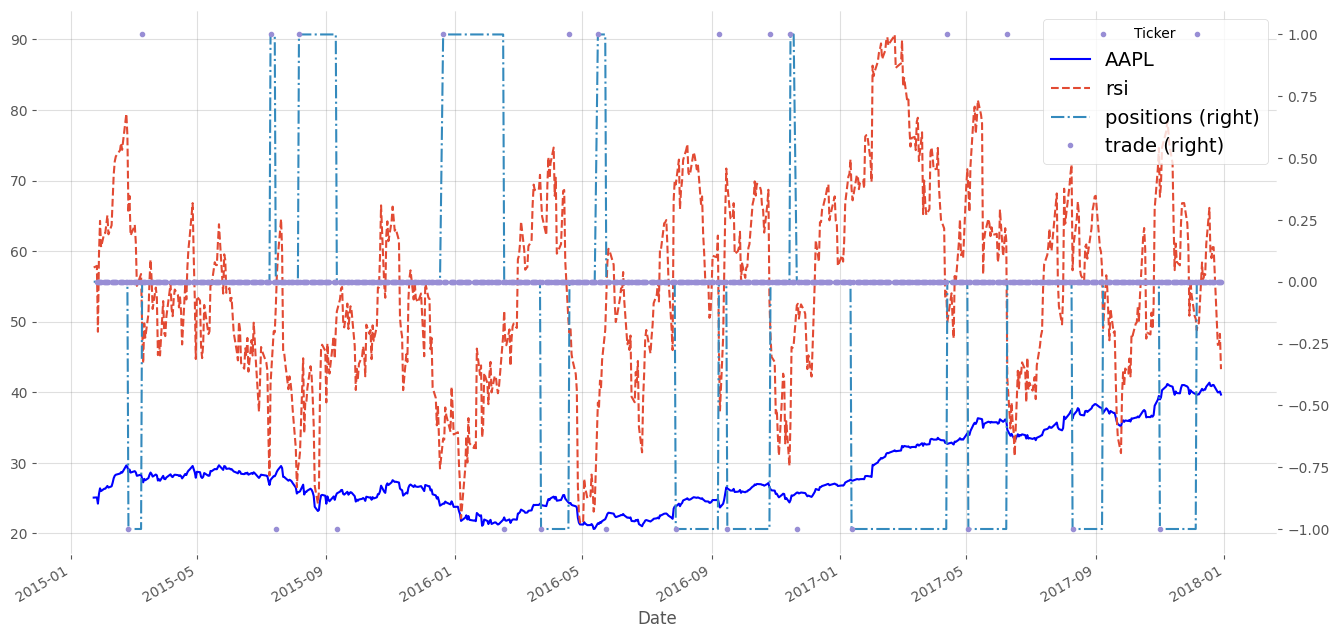

In [419]:
aapl.plot(
    secondary_y=['positions','trade'],
    figsize=[16,8],
    style=["b", "--", "-.", "."]
)

In [420]:
aapl

Ticker,AAPL,rsi,positions,trade
Date,,,,
2015-01-23,25.071007,57.671297,0.0,NaN
2015-01-26,25.097637,57.900004,0.0,0.0
2015-01-27,24.218885,48.573523,0.0,0.0
2015-01-28,25.588047,59.515607,0.0,0.0
2015-01-29,26.384695,64.278196,0.0,0.0
...,...,...,...,...
2017-12-22,41.025639,60.561009,0.0,0.0
2017-12-26,39.984829,46.701584,0.0,0.0
2017-12-27,39.991867,46.790261,0.0,0.0


### <font color = red> Answer 2 is presented in the cell below: </font>

In [421]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

aapl_melt = aapl.reset_index()
# aapl_melt = aapl_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='AAPL'), color='grey', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']>0.0], color='blue', size=3) +       # amend trade as required
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)

q =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='rsi'), color='green', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='rsi'), data=aapl_melt[aapl_melt['trade']>0.0], color='blue', size=3) +       # amend trade as required
    geom_point(aes(y='rsi'), data=aapl_melt[aapl_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("RSI with trades") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)

display(p)
display(q)

### <font color = blue> 👉 Question 3</font>. How much in cumulative returns could you have had as a result of the RSI strategy?

### Below are the lines of code that lead to an answer:

In [422]:
aapl =\
aapl.dropna()

In [423]:
aapl

Ticker,AAPL,rsi,positions,trade
Date,,,,
2015-01-26,25.097637,57.900004,0.0,0.0
2015-01-27,24.218885,48.573523,0.0,0.0
2015-01-28,25.588047,59.515607,0.0,0.0
2015-01-29,26.384695,64.278196,0.0,0.0
2015-01-30,25.998573,60.559584,0.0,0.0
...,...,...,...,...
2017-12-22,41.025639,60.561009,0.0,0.0
2017-12-26,39.984829,46.701584,0.0,0.0
2017-12-27,39.991867,46.790261,0.0,0.0


In [430]:
cum_rets =\
np.log(
    aapl['AAPL'] / aapl['AAPL'].shift(1)
)
aapl['strategy_returns'] =\
(
    cum_rets * aapl['positions'].shift(1)
).fillna(0)

In [432]:
np.exp(.05)

np.float64(1.0512710963760241)

In [445]:
initial_cap = 100_000
cap = initial_cap
cum_strategy_returns = pd.Series(index=aapl.index)

for idx, row in aapl.iterrows():
    cap *= np.exp(row['strategy_returns'])
    if row['trade'] !=0:
        cap -= 5
    cum_strategy_returns.loc[idx] = cap

print(f"Final capital ${cap:,.0f}")

Final capital $82,250


In [441]:
cagr=\
(
    (cap / initial_cap) ** (365.0 / (aapl.index[-1] -aapl.index[0]).days)  - 1
)

### <font color = red> Answer 3 </font>

    The answer is ____________ % .

In [444]:
f"The answer is {cagr:.2%}"

'The answer is -6.46%'

### <font color = blue> 👉 Question 4</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [477]:
df=\
(cum_strategy_returns / 
 cum_strategy_returns.cummax() -1).to_frame(name='daily_drawdown')

In [478]:
"""
 TODO max drawdown and duration table
"""
# take date column out and cumsum for periods
dd_reset = df.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)

In [479]:
period_stats

,start_date,end_date,avg_dd,max_dd,duration
period,,,,,
127,2015-08-11,2017-12-29,-0.147232,-0.284379,603
21,2015-02-25,2015-02-26,-0.006299,-0.012548,2
22,2015-03-02,2015-03-04,-0.004153,-0.006957,3
23,2015-03-06,2015-03-09,-0.003621,-0.005742,2
109,2015-07-14,2015-07-14,-0.000398,-0.000398,1
108,2015-07-10,2015-07-10,-0.000048,-0.000048,1
125,2015-08-06,2015-08-06,-0.000047,-0.000047,1


### <font color = red> Answer 4 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

In [483]:
for idx, row in period_stats.iterrows():
    print(f"The Worst drawdown period {row['start_date']} to {row['end_date']}  : Net drawdown {row['avg_dd']:.2%} % | Duration {row['duration']} Days")

The Worst drawdown period 2015-08-11 00:00:00 to 2017-12-29 00:00:00  : Net drawdown -14.72% % | Duration 603 Days
The Worst drawdown period 2015-02-25 00:00:00 to 2015-02-26 00:00:00  : Net drawdown -0.63% % | Duration 2 Days
The Worst drawdown period 2015-03-02 00:00:00 to 2015-03-04 00:00:00  : Net drawdown -0.42% % | Duration 3 Days
The Worst drawdown period 2015-03-06 00:00:00 to 2015-03-09 00:00:00  : Net drawdown -0.36% % | Duration 2 Days
The Worst drawdown period 2015-07-14 00:00:00 to 2015-07-14 00:00:00  : Net drawdown -0.04% % | Duration 1 Days
The Worst drawdown period 2015-07-10 00:00:00 to 2015-07-10 00:00:00  : Net drawdown -0.00% % | Duration 1 Days
The Worst drawdown period 2015-08-06 00:00:00 to 2015-08-06 00:00:00  : Net drawdown -0.00% % | Duration 1 Days


### <font color = blue> 👉 Question 5</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 5 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

###  <font color = blue> 👉 Question 6. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 6 </font>
    
    Sharpe ratio: __________
    

> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊